In [ ]:
import sys, os
sys.path.insert(0, os.path.join('..'))   # project root on path

import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import wrds
import polars as pl
import pyarrow
import config

from src.models.lightgbm import train_lgb
from sklearn.metrics import root_mean_squared_error

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
pd.set_option('display.float_format', '{:.4f}'.format)

Config window: 2000-01-01 → 2020-11-30


In [ ]:
"""

Read the features.parquet file and make the batch/split of the data

"""


features = pd.read_parquet(config.FEATURES_PATH_CLEAN)
print(f'Number of unique PERMNO in dataset : {features['PERMNO'].nunique()}')
from src.utils import generate_batches, train_val_test_split, split_batch

split_batch_dict = split_batch(features, 'PERMNO', 'date', config.BATCH_NUMBER, config.BATCH_SIZE, overlap=False)

Number of unique PERMNO in dataset : 6647


In [ ]:
""""

Unique batch test

"""


y_train = split_batch_dict['batch_1']['train']['target']
X_train = split_batch_dict['batch_1']['train'].drop(['target'], axis=1)
y_val = split_batch_dict['batch_1']['validation']['target']
X_val = split_batch_dict['batch_1']['validation'].drop(['target'], axis=1)


params = {
'objective': 'regression',
'metric': 'rmse',
'num_leaves': 31,
'learning_rate': 0.05,
'feature_fraction': 0.9
}


In [4]:
lgb_model = train_lgb(X_train, y_train, X_val, y_val, params)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.033406 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4590
[LightGBM] [Info] Number of data points in the train set: 1068364, number of used features: 18
[LightGBM] [Info] Start training from score 0.000741


(array([3.00000e+00, 0.00000e+00, 0.00000e+00, 2.00000e+00, 3.00000e+00,
        6.00000e+00, 1.20000e+01, 3.60000e+01, 6.50000e+01, 1.58000e+02,
        5.32000e+02, 3.13100e+03, 1.06851e+05, 5.54000e+03, 9.70000e+02,
        3.38000e+02, 1.42000e+02, 7.60000e+01, 4.40000e+01, 2.90000e+01,
        2.50000e+01, 1.60000e+01, 1.00000e+01, 6.00000e+00, 7.00000e+00]),
 array([-5. , -4.6, -4.2, -3.8, -3.4, -3. , -2.6, -2.2, -1.8, -1.4, -1. ,
        -0.6, -0.2,  0.2,  0.6,  1. ,  1.4,  1.8,  2.2,  2.6,  3. ,  3.4,
         3.8,  4.2,  4.6,  5. ]),
 <BarContainer object of 25 artists>)

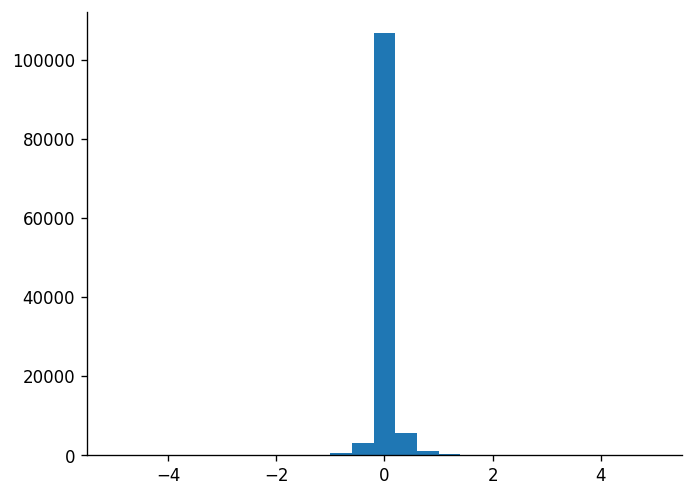

In [5]:
y_pred =lgb_model.predict(X_val)
plt.hist(y_pred * 100, range=[-5,5], bins=25)